In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as db
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.get_all_data import get_all_data
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-06-17 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-04-14 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

In [3]:
hmm = joblib.load('../models/hmm_model.pkl')
pca = joblib.load('../models/pca.pkl')
scaler = joblib.load('../models/scaler.pkl')

In [4]:
X_scaled = scaler.transform(df)
X_pca    = pca.transform(X_scaled)

n_states = hmm.n_components
state_probs = hmm.predict_proba(X_pca)
state_predict = hmm.predict(X_pca)


df['state'] = state_predict

for i in range(n_states):
    df[f'prob_state_{i}'] = state_probs[:, i]

df['confidence'] = state_probs.max(axis=1)
df['entropy'] = -np.sum(state_probs * np.log(state_probs + 1e-8), axis=1)
df['prev_state'] = df['state'].shift(1)
df['state_change'] = (df['state'] != df['prev_state']).astype(int)

duration = []
count = 1

for i in range(len(df)):
    if i == 0:
        duration.append(1)
    elif df['state'].iloc[i] == df['state'].iloc[i-1]:
        count += 1
        duration.append(count)
    else:
        count = 1
        duration.append(count)

df['state_duration'] = duration

window = 5

df['confidence_roll'] = df['confidence'].rolling(window).mean()

for i in range(n_states):
    df[f'prob_state_{i}_roll'] = df[f'prob_state_{i}'].rolling(window).mean()


future_window = 3

df['future_state'] = df['state'].shift(-future_window)
df['valid_change'] = (df['state'] == df['future_state']).astype(int)

df_ml = df[df['state_change'] == 1].dropna() #only uses the moment when has a change

In [5]:
features = [
    'confidence',
    'entropy',
    'state_duration',
    'confidence_roll',
]

features += [f'prob_state_{i}_roll' for i in range(n_states)]

In [6]:
X = df_ml[features]
y = df_ml['valid_change']

In [7]:

meta_model = RandomForestClassifier(
    n_estimators=1500,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

meta_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [8]:
final_states = []

for i in range(len(df)):
    if i == 0:
        final_states.append(df['state'].iloc[i])
        continue

    current_state = df['state'].iloc[i]
    prev_state = final_states[-1]

    if current_state != prev_state:
        X_t = df.iloc[i][features].values.reshape(1, -1)
        proba = meta_model.predict_proba(X_t)[0][1]

        if proba > 0.75:
            final_states.append(current_state)
        else:
            final_states.append(prev_state)
    else:
        final_states.append(current_state)

df['filtered_state'] = final_states

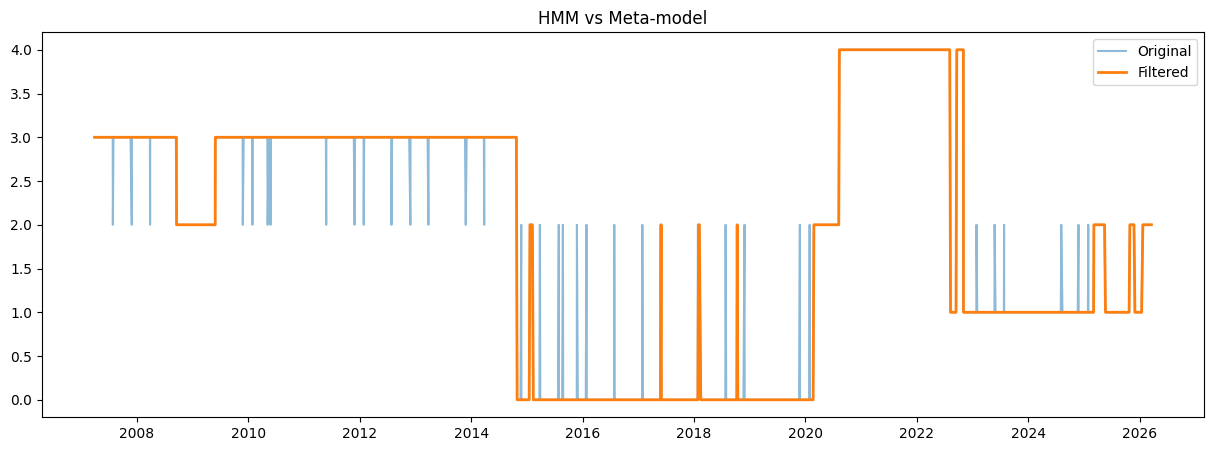

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['state'], label='Original', alpha=0.5)
plt.plot(df['filtered_state'], label='Filtered', linewidth=2)
plt.legend()
plt.title("HMM vs Meta-model")
plt.show()

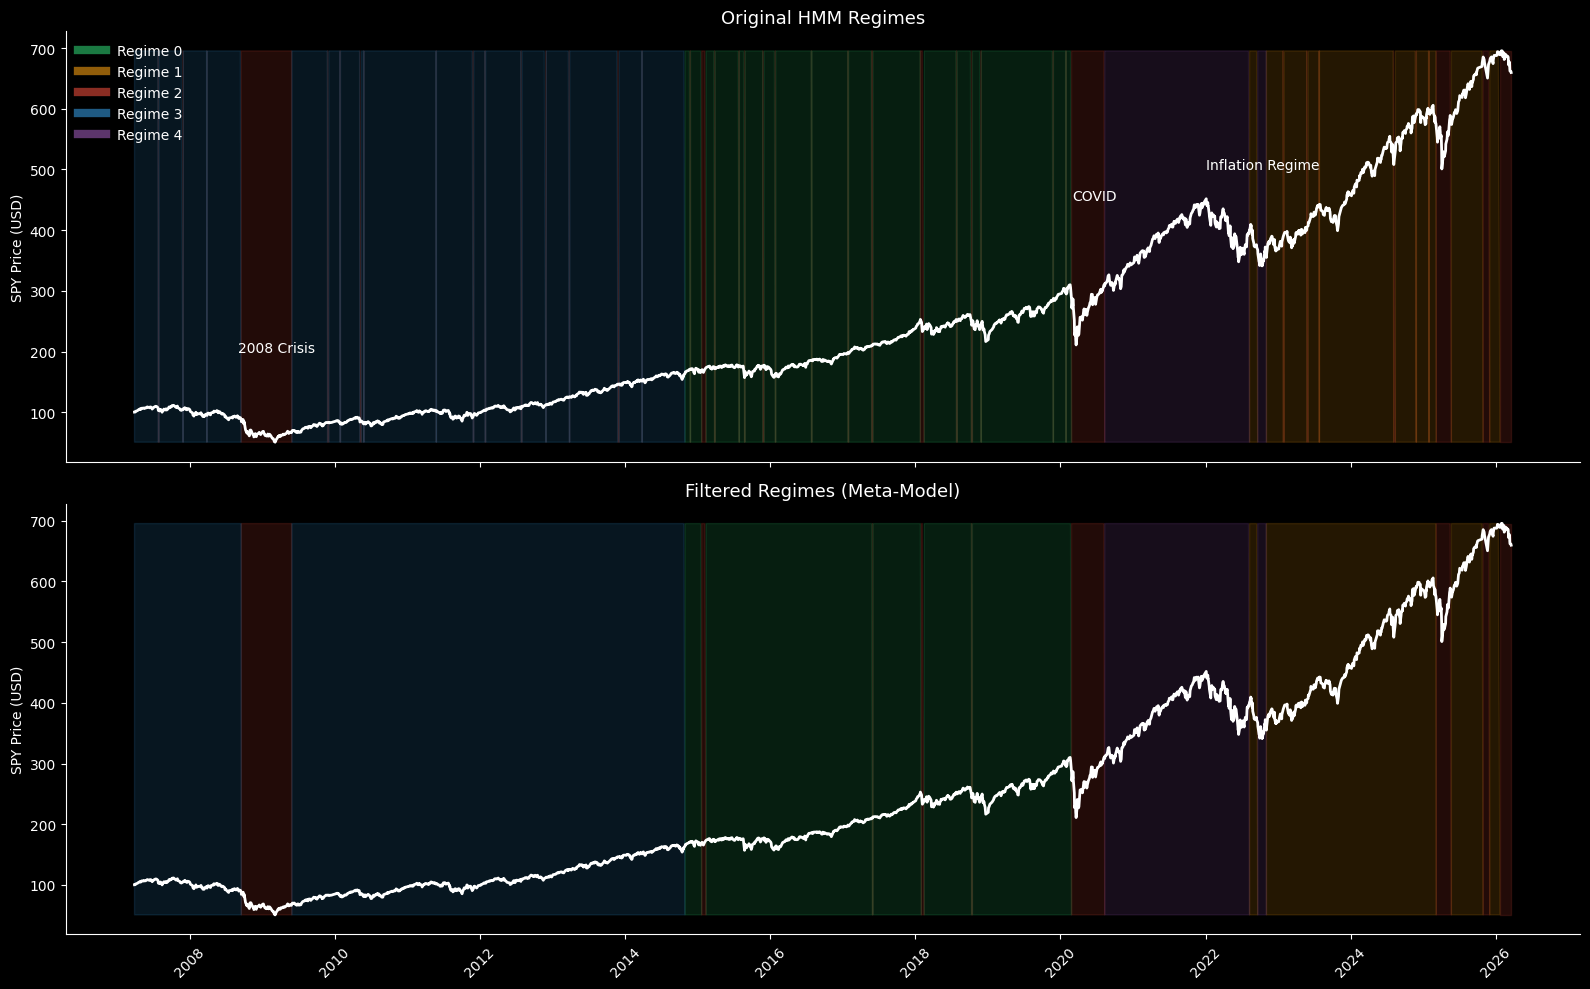

In [10]:
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

n_states = hmm.n_components

colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6', '#e84393'][:n_states]

#Hmm model
ax = axes[0]

ax.plot(df.index, df['spy_close'], color='white', lw=2)

ax.set_ylabel('SPY Price (USD)')
ax.set_title('Original HMM Regimes', fontsize=13)

for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id

    ax.fill_between(
        df.index,
        df['spy_close'].min(),
        df['spy_close'].max(),
        where=mask,
        color=color,
        alpha=0.15,
        interpolate=True
    )

#Meta Model
ax2 = axes[1]

ax2.plot(df.index, df['spy_close'], color='white', lw=2)

ax2.set_ylabel('SPY Price (USD)')
ax2.set_title('Filtered Regimes (Meta-Model)', fontsize=13)

for regime_id, color in enumerate(colors):
    mask = df['filtered_state'] == regime_id

    ax2.fill_between(
        df.index,
        df['spy_close'].min(),
        df['spy_close'].max(),
        where=mask,
        color=color,
        alpha=0.15,
        interpolate=True
    )

axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([0], [0], color=color, lw=6, alpha=0.6)
    for color in colors
]

labels = [f'Regime {i}' for i in range(n_states)]

axes[0].legend(handles, labels, loc='upper left', frameon=False)

axes[0].text(pd.Timestamp('2008-09-01'), 200, '2008 Crisis', color='white')
axes[0].text(pd.Timestamp('2020-03-01'), 450, 'COVID', color='white')
axes[0].text(pd.Timestamp('2022-01-01'), 500, 'Inflation Regime', color='white')

plt.tight_layout()
plt.savefig('regimes_comparison.png', dpi=300, bbox_inches='tight')

plt.show()